PREPARACIÓN DEL ENTORNO Y LIBRERÍAS

In [ ]:
!pip install quimb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 941.6/941.6 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 40.5 MB/s eta 0:00:00


In [ ]:
!pip install tensorcircuit
!pip install qibo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.0/342.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.1/244.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.2/356.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.7/269.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.7 MB/s eta 0:00:00


In [ ]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
qibo 0.3.3 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorcircuit as tc
import tensorflow as tf

from qibo.hamiltonians import TFIM

TensorCircuit internamente usa tensor networks

**Resolver el modelo de Ising cuántico (TFIM) usando: VQE (Variational Quantum Eigensolver), buscando: los parámetros θ que minimizan la energía**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import quimb as q
import quimb.tensor as qtn

import tensorcircuit as tc
import tensorflow as tf

tc.set_backend("tensorflow")
tc.set_dtype("complex64")

zz = np.kron(tc.gates._z_matrix, tc.gates._z_matrix)
print(zz)

[[ 1.  0.  0.  0.]
 [ 0. -1.  0. -0.]
 [ 0.  0. -1. -0.]
 [ 0. -0. -0.  1.]]


In [ ]:
def exact_energy_tf(L, j=1.0, h=1):
    H = qtn.MPO_ham_ising(L, j=j, bx=h).to_dense()
    eigs = np.linalg.eigvalsh(H)
    return np.min(eigs)

In [ ]:
def dmrg_energy(L, j=1.0, bx=0.5, bond_dims=[32,64,128,256]):
    H = qtn.MPO_ham_ising(L, j=j, bx=bx)

    dmrg = qtn.DMRG2(
        H,
        bond_dims=bond_dims
    )

    dmrg.solve(verbosity=0, tol=1e-6)

    return dmrg.energy

In [ ]:
def vqe_energy(param, L, nlayers, j=1.0, h=1.0):

    zz = np.kron(tc.gates._z_matrix, tc.gates._z_matrix)

    c = tc.Circuit(L)

    param = tc.backend.cast(param, tc.dtypestr)

    for i in range(L):
        c.H(i)

    for l in range(nlayers):
        for i in range(L - 1):
            c.exp1(i, i + 1, unitary=zz, theta=param[2*l, i])

        for i in range(L):
            c.rx(i, theta=param[2*l + 1, i])


    e = 0.0
    for i in range(L):
        # Cambiamos h por h/2 para coincidir con espín-1/2
        e += -(h / 2.0) * c.expectation((tc.gates.x(), [i]))

    for i in range(L - 1):
        # Cambiamos j por j/4 para coincidir con espín-1/4
        e += -(j / 4.0) * c.expectation(
            (tc.gates.z(), [i]),
            (tc.gates.z(), [i + 1])
        )

    return tc.backend.real(e)


def train_vqe(L, nlayers=2, steps=300):

    param = tf.Variable(
        tf.random.normal([2*nlayers, L], stddev=0.1)
    )

    opt = tf.keras.optimizers.Adam(0.01)

    for i in range(steps):

        with tf.GradientTape() as tape:
            e = vqe_energy(param, L, nlayers)

        grad = tape.gradient(e, param)
        opt.apply_gradients([(grad, param)])

        if i % 100 == 0:
            print(f"VQE step {i}: energy = {e.numpy():.6f}")

    return float(e.numpy())

In [9]:
import time

def experiment():

    L_list = [4, 6,8,10,12]

    vqe_E = []
    dmrg_E = []
    exact_E = []

    times_vqe = []
    times_dmrg = []
    times_exact=[]
    nlayers = 2

    for L in L_list:

        print("L =", L)

        # -------- EXACTO --------

        if L <= 10:
            E_exact = exact_energy_tf(L)
        else:
            E_exact = np.nan

        # -------- DMRG --------
        start = time.time()

        E_dmrg = dmrg_energy(L)

        t_dmrg = time.time() - start

        # -------- VQE --------
        start = time.time()

        E_vqe = train_vqe(L, nlayers)

        t_vqe = time.time() - start



        exact_E.append(E_exact)
        dmrg_E.append(E_dmrg)
        vqe_E.append(E_vqe)

        times_dmrg.append(t_dmrg)
        times_vqe.append(t_vqe)

    return (
        L_list,
        vqe_E,
        dmrg_E,
        exact_E,
        times_vqe,
        times_dmrg,

    )

In [10]:
L_list, vqe_E, dmrg_E, exact_E, times_vqe, times_dmrg= experiment()

L = 4
VQE step 0: energy = -1.785804
VQE step 100: energy = -2.089348
VQE step 200: energy = -2.089684
L = 6
VQE step 0: energy = -2.958904
VQE step 100: energy = -3.148433
VQE step 200: energy = -3.150390
L = 8
VQE step 0: energy = -3.680086
VQE step 100: energy = -4.206597
VQE step 200: energy = -4.208378
L = 10
VQE step 0: energy = -4.846679
VQE step 100: energy = -5.268241
VQE step 200: energy = -5.271984
L = 12
VQE step 0: energy = -5.808910
VQE step 100: energy = -6.327692
VQE step 200: energy = -6.332546


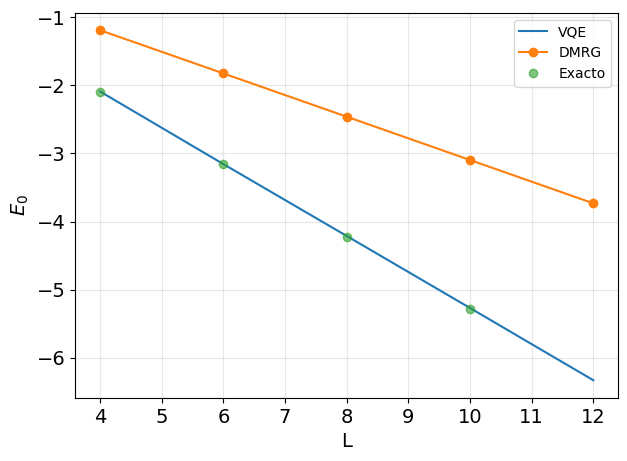

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,5))

plt.plot(L_list, vqe_E, '-', label="VQE")
plt.plot(L_list, dmrg_E, 'o-', label="DMRG")
plt.plot(L_list, exact_E, 'o', alpha=0.6,label="Exacto")

plt.xlabel("L",fontsize=14)
plt.ylabel(r"$E_0$",fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

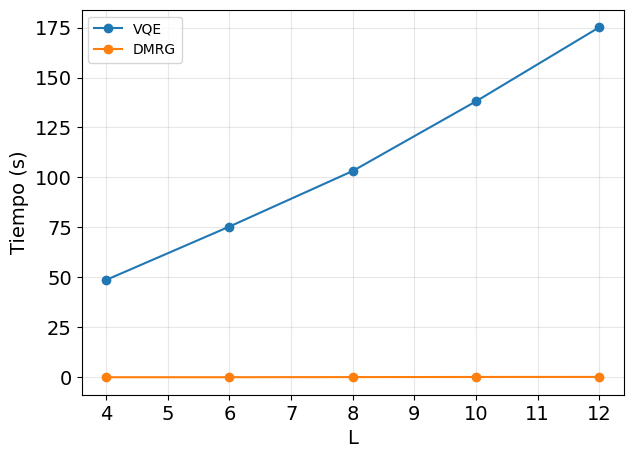

In [12]:
plt.figure(figsize=(7,5))

plt.plot(L_list, times_vqe, 'o-', label='VQE')
plt.plot(L_list, times_dmrg, 'o-', label='DMRG')

plt.xlabel('L',fontsize=14)
plt.ylabel('Tiempo (s)',fontsize=14)

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()